## Hotel Business Operation Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path='/content/hotel_bookings.csv'

In [3]:
df=pd.read_csv(file_path)

In [4]:
df.sample(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
118678,City Hotel,0,172,2017,August,34,21,1,2,2,...,No Deposit,7.0,NaN,0,Transient,125.17,0,0,Check-Out,2017-08-24
100020,City Hotel,0,19,2016,October,43,21,0,1,2,...,No Deposit,9.0,NaN,0,Transient,140.00,0,2,Check-Out,2016-10-22
50871,City Hotel,1,68,2016,May,20,10,0,3,1,...,No Deposit,9.0,NaN,0,Transient,121.50,0,0,Canceled,2016-03-03
102233,City Hotel,0,212,2016,November,47,18,2,5,2,...,No Deposit,NaN,233.0,0,Transient-Party,165.00,0,0,Check-Out,2016-11-25
69910,City Hotel,1,181,2017,June,23,8,0,2,2,...,Non Refund,58.0,NaN,0,Transient,100.00,0,0,Canceled,2017-01-24


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


##Data PreProcessing

In [7]:
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
# Fill missing values in 'children' with the median
median_children = df['children'].median()
df['children'].fillna(median_children, inplace=True)

# Fill missing values in 'country' with the mode
mode_country = df['country'].mode()[0]
df['country'].fillna(mode_country, inplace=True)

# Fill missing values in 'agent' and 'company' with mode as these fields have most repetative Agent and Company IDs
mode_agent = df['agent'].mode()[0]
df['agent'].fillna(mode_agent, inplace=True)

mode_company = df['company'].mode()[0]
df['company'].fillna(mode_company, inplace=True)

/tmp/ipykernel_5126/712723338.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(median_children, inplace=True)
/tmp/ipykernel_5126/712723338.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [47]:
print('\nMissing values after imputation:\n', df.isnull().sum())


Missing values after imputation:
 hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                

In [10]:
df.sample(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
9203,Resort Hotel,1,42,2016,November,45,2,0,3,2,...,No Deposit,240.0,40.0,0,Transient,55.8,0,2,Canceled,2016-10-01
35309,Resort Hotel,0,0,2017,April,16,17,1,0,2,...,No Deposit,9.0,40.0,0,Transient,91.0,0,0,Check-Out,2017-04-18
88354,City Hotel,0,27,2016,May,19,4,0,1,2,...,No Deposit,138.0,40.0,0,Transient,85.0,0,0,Check-Out,2016-05-05
80730,City Hotel,1,73,2015,December,53,31,0,3,2,...,No Deposit,104.0,40.0,0,Transient,99.0,0,0,Canceled,2015-11-23
79839,City Hotel,1,34,2015,December,50,8,0,2,1,...,Non Refund,19.0,40.0,0,Transient,90.0,0,0,Canceled,2015-11-06


In [48]:
# Combine year, month, and day to create a proper 'arrival_date' column
df['arrival_date'] = pd.to_datetime(df['arrival_date_year'].astype(str) + '-' +
                                    df['arrival_date_month'].astype(str) + '-' +
                                    df['arrival_date_day_of_month'].astype(str), errors='coerce')

# Convert 'reservation_status_date' to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], errors='coerce')

In [49]:
print('Data types after date conversion:')
df[['arrival_date', 'reservation_status_date']].info()

Data types after date conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 87376 entries, 0 to 119389
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   arrival_date             87376 non-null  datetime64[ns]
 1   reservation_status_date  87376 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 2.0 MB


## Handling Duplicate Entries

In [13]:
print(f"Initial number of rows: {df.shape[0]}")
duplicate_rows_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows_count}")

if duplicate_rows_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after removing duplicates: {df.shape[0]}")
else:
    print("No duplicate rows found.")

Initial number of rows: 119390
Number of duplicate rows found: 32014
Number of rows after removing duplicates: 87376


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87376 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87376 non-null  object        
 1   is_canceled                     87376 non-null  int64         
 2   lead_time                       87376 non-null  int64         
 3   arrival_date_year               87376 non-null  int64         
 4   arrival_date_month              87376 non-null  object        
 5   arrival_date_week_number        87376 non-null  int64         
 6   arrival_date_day_of_month       87376 non-null  int64         
 7   stays_in_weekend_nights         87376 non-null  int64         
 8   stays_in_week_nights            87376 non-null  int64         
 9   adults                          87376 non-null  int64         
 10  children                        87376 non-null  float64       
 11  babies

## EDA :Lets Deep Dive into Data Insights for informed Decision making

# Analysis of Booking Distribution

### Distribution of Bookings by Hotel Type

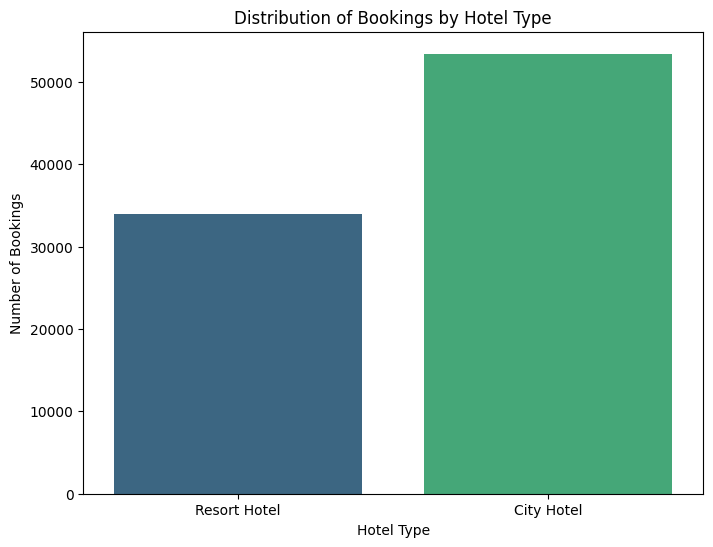

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='hotel', palette='viridis', hue='hotel', legend=False)
plt.title('Distribution of Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.show()

#Business Impact:
* Helps in targeting marketing efforts appropriately.
* Shows the popularity of Hotel Type

### Distribution of Bookings by Arrival Month

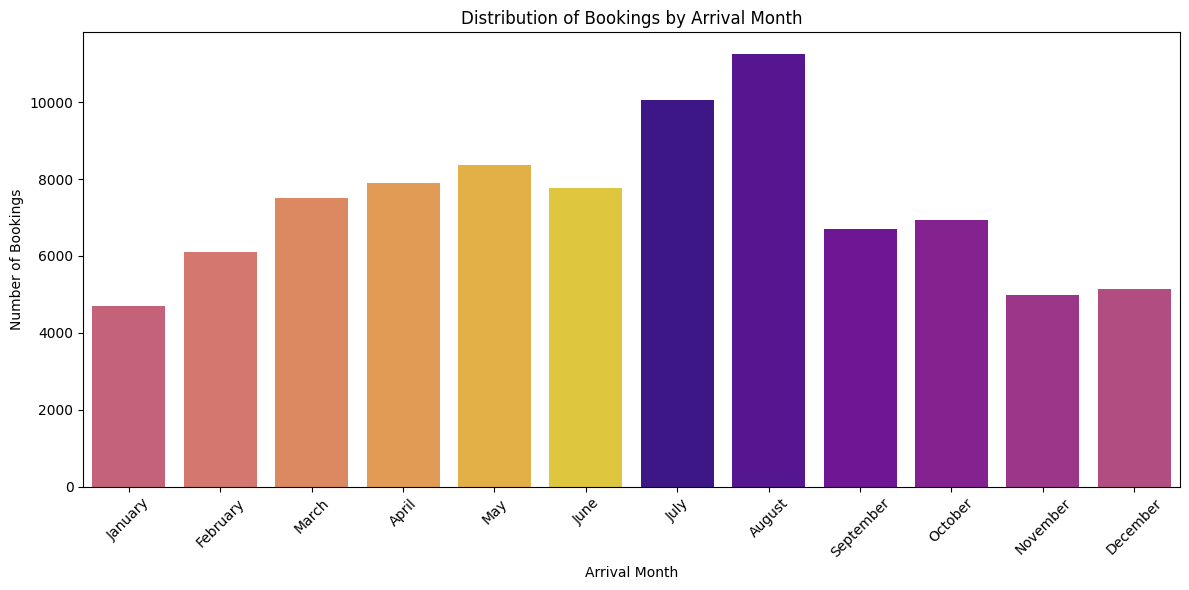

In [50]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='arrival_date_month', order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], palette='plasma', hue='arrival_date_month', legend=False)
plt.title('Distribution of Bookings by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Bookings by Market Segment

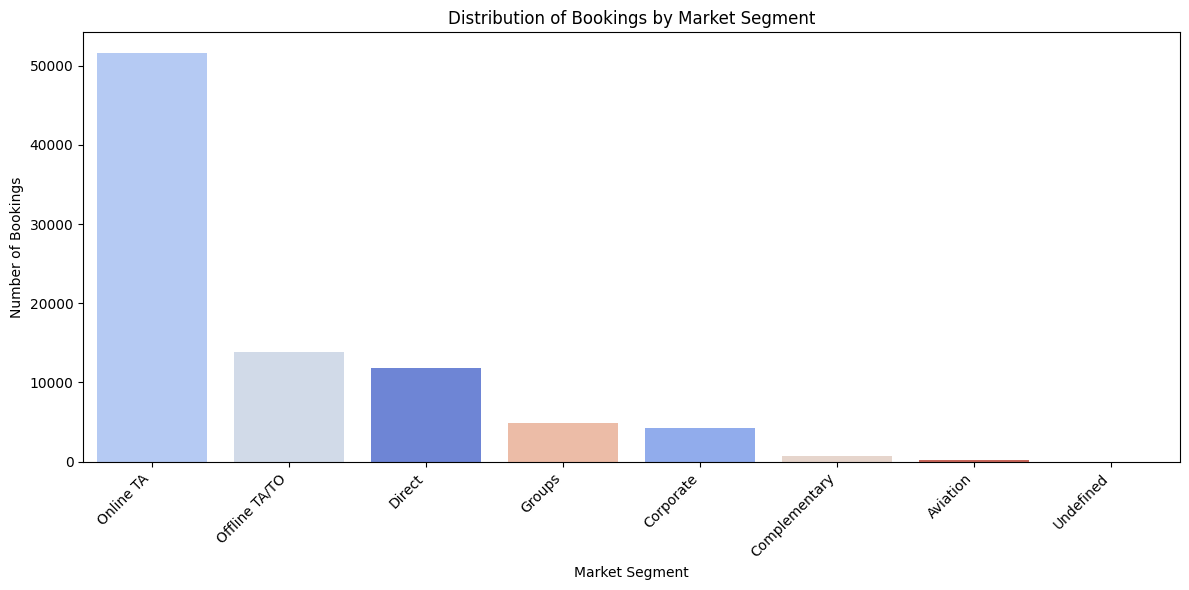

In [51]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='market_segment', palette='coolwarm', order=df['market_segment'].value_counts().index, hue='market_segment', legend=False)
plt.title('Distribution of Bookings by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Correlation between Lead Time and Cancellation Rate

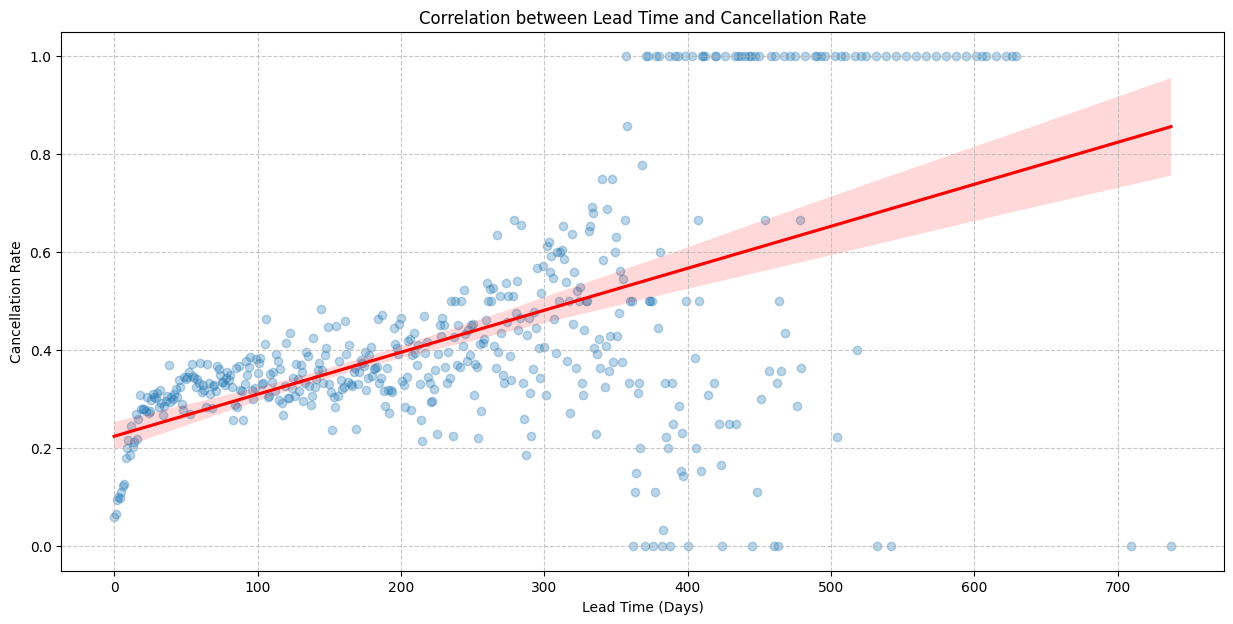

In [52]:
cancellation_by_lead_time = df.groupby('lead_time')['is_canceled'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.regplot(data=cancellation_by_lead_time, x='lead_time', y='is_canceled', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation between Lead Time and Cancellation Rate')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancellation Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Trend of Average Daily Rate (ADR) Over Time

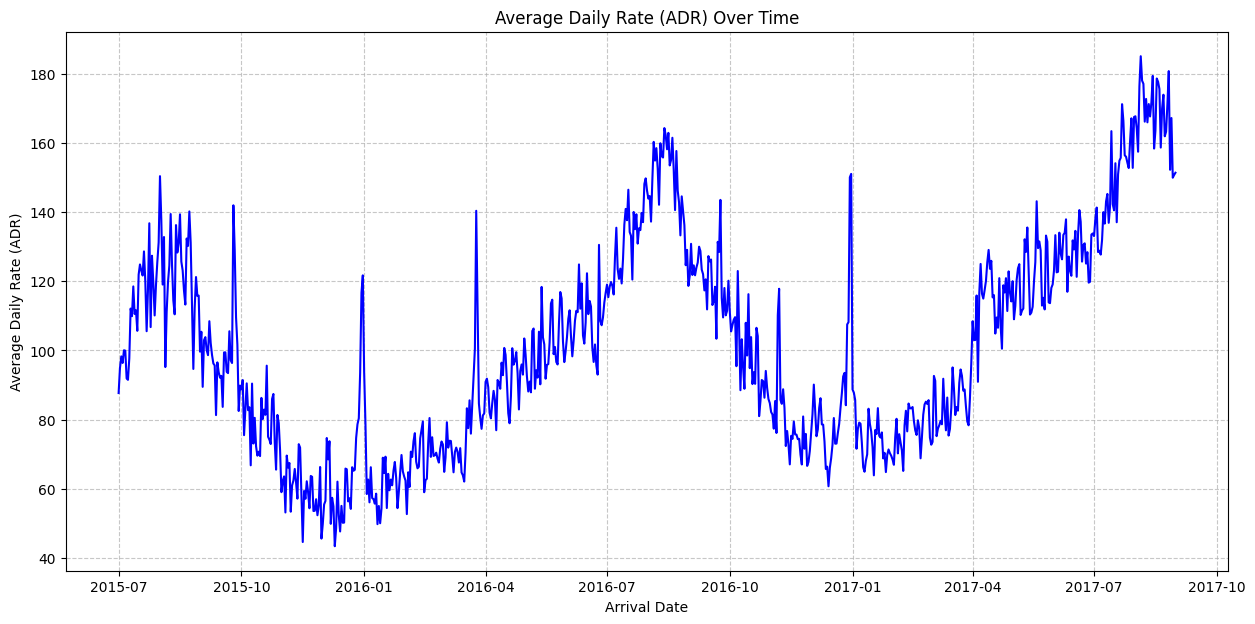

In [53]:
adr_over_time = df.groupby('arrival_date')['adr'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=adr_over_time, x='arrival_date', y='adr', color='blue')
plt.title('Average Daily Rate (ADR) Over Time')
plt.xlabel('Arrival Date')
plt.ylabel('Average Daily Rate (ADR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Impact of Special Requests on Cancellation Rate (Guest Satisfaction)

/tmp/ipykernel_5126/1788076099.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancellation_by_special_requests, x='total_of_special_requests', y='is_canceled', palette='viridis')


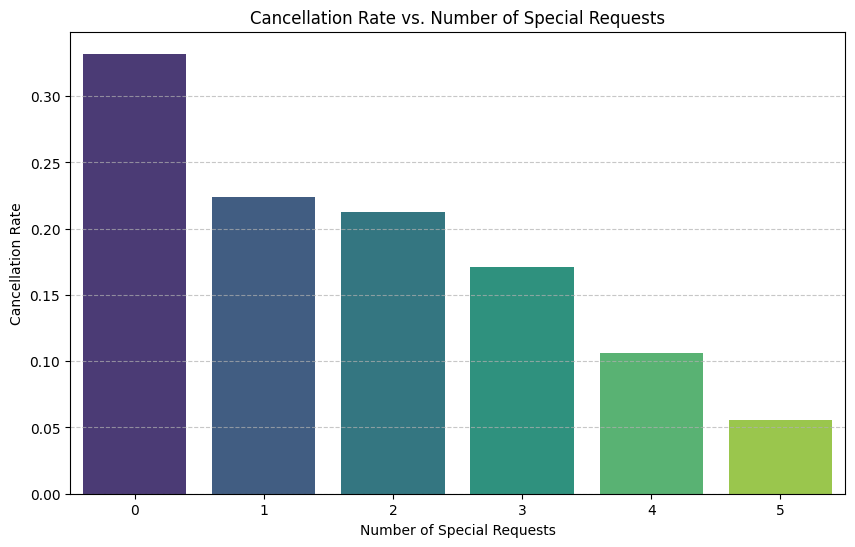

In [54]:
cancellation_by_special_requests = df.groupby('total_of_special_requests')['is_canceled'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=cancellation_by_special_requests, x='total_of_special_requests', y='is_canceled', palette='viridis')
plt.title('Cancellation Rate vs. Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [55]:
average_lead_time = df['lead_time'].mean()
print(f"The average lead time for bookings is: {average_lead_time:.2f} days")

The average lead time for bookings is: 79.91 days


# Business Impact:
* Avg Lead Time helps in predicting booking trends and planning marketing campaigns accordingly.

In [56]:
canceled_bookings = df['is_canceled'].sum()
print(f"Total number of canceled bookings: {canceled_bookings}")

Total number of canceled bookings: 24024


#Business Impact:

* Helps in developing strategies to reduce cancellations.
* Provides insight into booking reliability.

In [57]:
most_common_arrival_month = df['arrival_date_month'].mode()[0]
print(f"The most common arrival month for bookings is: {most_common_arrival_month}")

The most common arrival month for bookings is: August


#Business Impact:

* Aids in resource and staff planning for peak seasons.
* Identifies peak booking periods.


In [58]:
average_special_requests = df['total_of_special_requests'].mean()
print(f"The average number of special requests per booking is: {average_special_requests:.2f}")

The average number of special requests per booking is: 0.70


#Business Impact:

* Improves customer satisfaction by meeting their requests.
* Understands customer service requirements.


In [59]:
most_bookings_country = df['country'].value_counts().idxmax()
print(f"The country with the highest number of bookings is: {most_bookings_country}")

The country with the highest number of bookings is: PRT


#Business Impact:

* Focuses marketing efforts on key regions.
* Identifies major customer demographics.

In [60]:
avg_adr_by_hotel = df.groupby('hotel')['adr'].mean().reset_index()
print("Average Daily Rate (ADR) for each Hotel Type:")
print(avg_adr_by_hotel)

Average Daily Rate (ADR) for each Hotel Type:
          hotel         adr
0    City Hotel  110.985832
1  Resort Hotel   99.041495


#Business Impact:

*  Informs pricing and revenue management strategies.
*  Compares financial performance of different hotel types.

In [61]:
car_parking_required = df[df['required_car_parking_spaces'] > 0].shape[0]
total_bookings = df.shape[0]
percentage_car_parking = (car_parking_required / total_bookings) * 100
print(f"Percentage of guests who required car parking spaces: {percentage_car_parking:.2f}%")

Percentage of guests who required car parking spaces: 8.37%


# Business Impact:

* Ensures adequate parking availability for guests.
* Assesses the demand for parking facilities.

In [62]:
average_week_nights = df['stays_in_week_nights'].mean()
average_weekend_nights = df['stays_in_weekend_nights'].mean()

print(f"Average stay duration in week nights: {average_week_nights:.2f} nights")
print(f"Average stay duration in weekend nights: {average_weekend_nights:.2f} nights")

Average stay duration in week nights: 2.63 nights
Average stay duration in weekend nights: 1.01 nights


# Business Impact:

* Helps in optimizing room occupancy and pricing strategies.
* Helps in Understanding Booking Pattern

In [63]:
bookings_through_agent = df['agent'].count()
print(f"Number of bookings made through travel agents: {bookings_through_agent}")

Number of bookings made through travel agents: 87376


Business Impact:

* Helps in managing relationships with travel agents effectively.
* Identifies the importance of travel agents in booking processes.

In [64]:
cancellation_rate_by_hotel = df.groupby('hotel')['is_canceled'].mean().reset_index()
print("Cancellation Rate for each Hotel Type:")
print(cancellation_rate_by_hotel)

Cancellation Rate for each Hotel Type:
          hotel  is_canceled
0    City Hotel     0.300391
1  Resort Hotel     0.234911


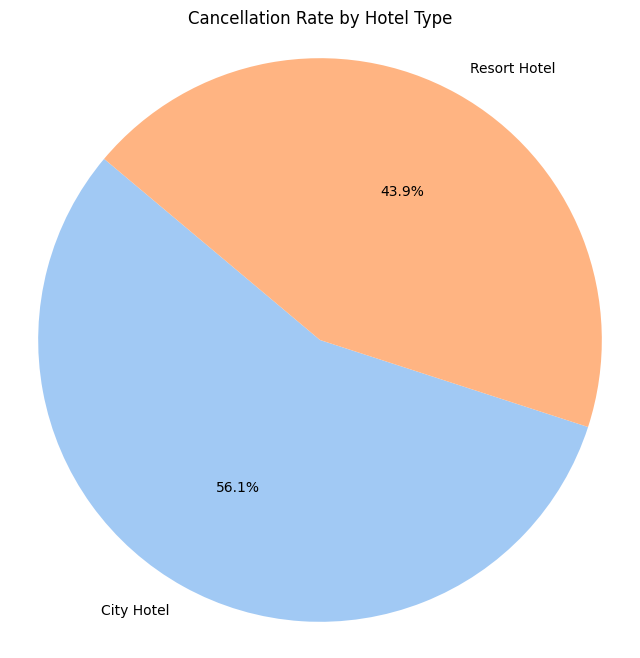

In [65]:
plt.figure(figsize=(8, 8))
plt.pie(cancellation_rate_by_hotel['is_canceled'], labels=cancellation_rate_by_hotel['hotel'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Cancellation Rate by Hotel Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

#Business Impact:

* Helps in developing strategies to reduce cancellations for specific hotel types.
* Helps in Identying which hotel type has a higher cancellation rate.

### Distribution Channel with the Highest Number of Bookings

In [66]:
most_bookings_channel = df['distribution_channel'].value_counts().idxmax()
print(f"The distribution channel with the highest number of bookings is: {most_bookings_channel}")

The distribution channel with the highest number of bookings is: TA/TO


# Business Impact:
* Helps in optimizing partnerships with various distribution channels.
* Identifies the most effective channels for acquiring bookings.
* Helps in focusing efforts on the most productive channels.
* Identifies the most effective booking channels.

### Average Number of Previous Cancellations by Hotel Type

In [67]:
avg_prev_cancellations_by_hotel = df.groupby('hotel')['previous_cancellations'].mean().reset_index()
print("Average number of previous cancellations by hotel type:")
print(avg_prev_cancellations_by_hotel)

Average number of previous cancellations by hotel type:
          hotel  previous_cancellations
0    City Hotel                0.035768
1  Resort Hotel                0.022004


# Business Impact:
* Helps to understand customer loyalty and retention issues for each hotel type.
* Provides insights for targeted loyalty programs or service improvements to reduce cancellations.
*  Helps in developing targeted strategies to reduce cancellations.
* Understands past cancellation behavior by hotel type.

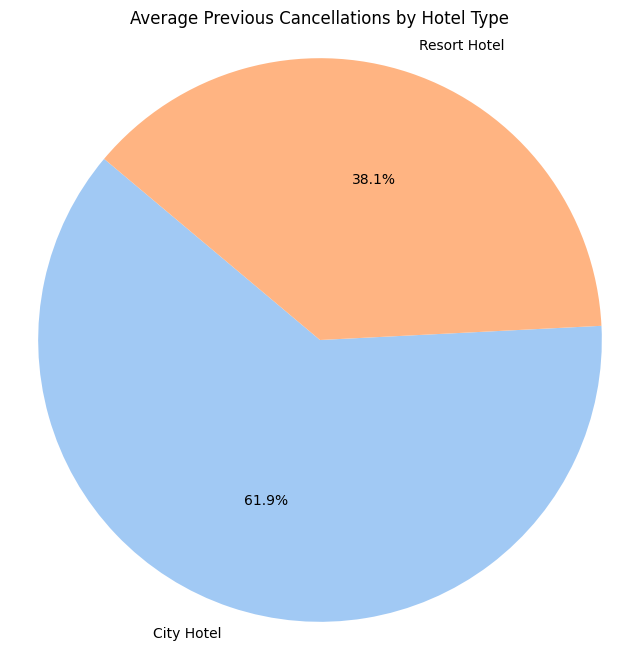

In [68]:
plt.figure(figsize=(8, 8))
plt.pie(avg_prev_cancellations_by_hotel['previous_cancellations'], labels=avg_prev_cancellations_by_hotel['hotel'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Average Previous Cancellations by Hotel Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Trend of Average Daily Rate (ADR) Over the Years

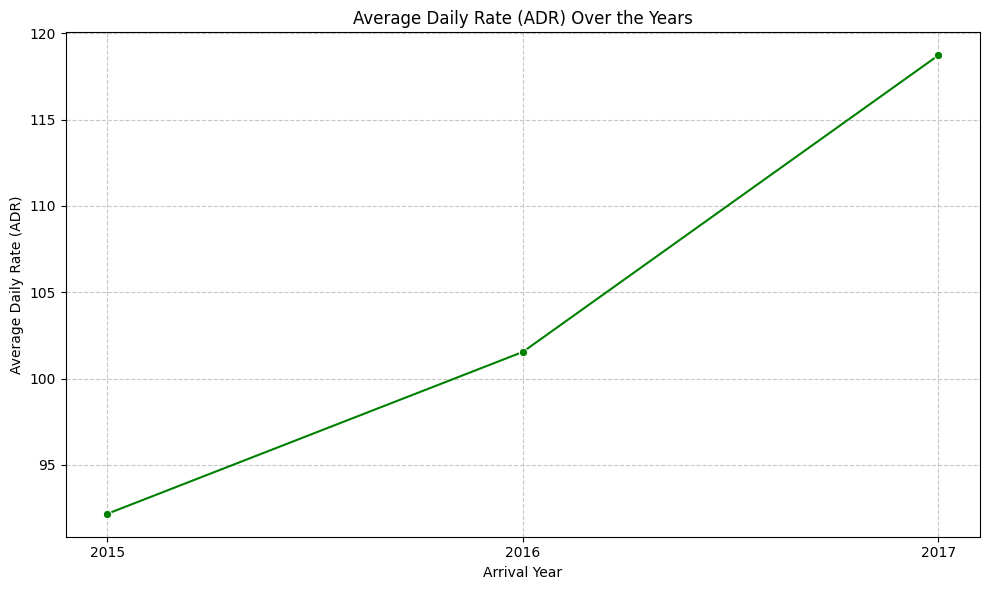

In [69]:
adr_by_year = df.groupby('arrival_date_year')['adr'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=adr_by_year, x='arrival_date_year', y='adr', marker='o', color='green')
plt.title('Average Daily Rate (ADR) Over the Years')
plt.xlabel('Arrival Year')
plt.ylabel('Average Daily Rate (ADR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(adr_by_year['arrival_date_year'].unique()) # Ensure all years are shown as ticks
plt.tight_layout()
plt.show()

# Business Impact:
* Provides insights into pricing strategies and their
  effectiveness over time.
* Helps in identifying periods of high and low demand, guiding
  future pricing adjustments.
* Informs long-term pricing and revenue management strategies.
* Identifies changes in ADR over time.

### Month with the Highest Revenue

The month with the highest revenue is: August with a total revenue of 7240652.99


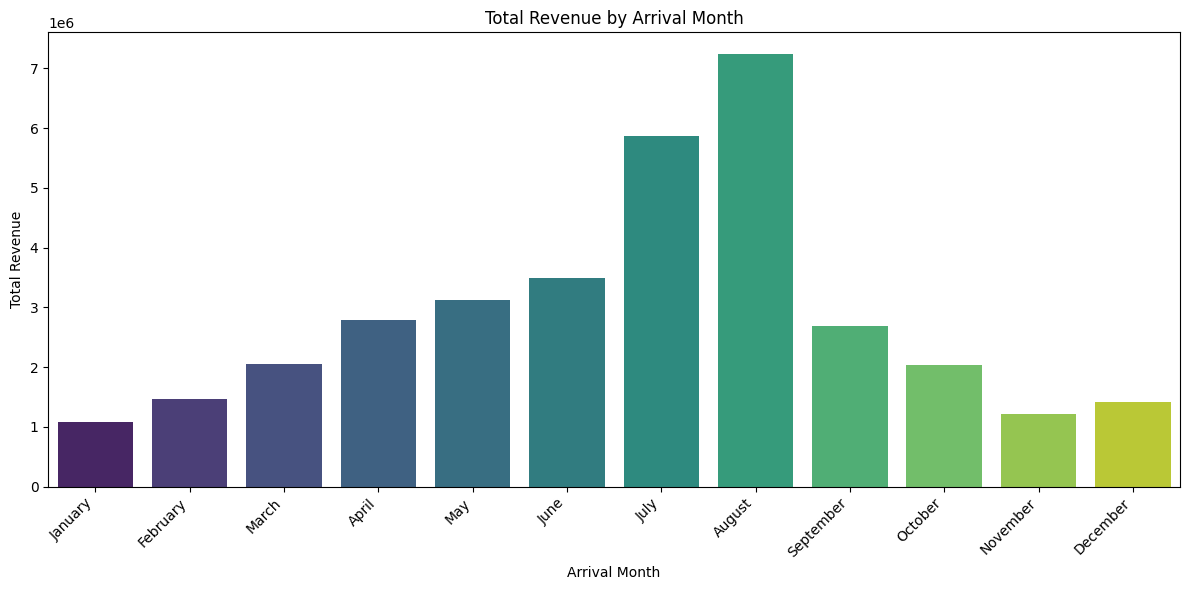

In [70]:
# Calculate total stay nights
df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Calculate total revenue per booking
df['total_revenue'] = df['adr'] * df['total_stay_nights']

# Group by month and sum the total revenue
monthly_revenue = df.groupby('arrival_date_month')['total_revenue'].sum().reset_index()

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_revenue['arrival_date_month'] = pd.Categorical(monthly_revenue['arrival_date_month'], categories=month_order, ordered=True)
monthly_revenue = monthly_revenue.sort_values('arrival_date_month')

# Find the month with the highest revenue
highest_revenue_month = monthly_revenue.loc[monthly_revenue['total_revenue'].idxmax()]

print(f"The month with the highest revenue is: {highest_revenue_month['arrival_date_month']} with a total revenue of {highest_revenue_month['total_revenue']:.2f}")

# Visualize the monthly revenue
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_revenue, x='arrival_date_month', y='total_revenue', palette='viridis', hue='arrival_date_month', legend=False)
plt.title('Total Revenue by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Business Impact:
* Guides marketing efforts and promotions for months with lower revenue.
* Optimizes staffing and resource allocation based on revenue forecasts.
* Helps in strategic planning for peak revenue months.
* Helps in planning promotional activities and resource
  allocation.
* Identifies the most profitable months.  

### Impact of Special Requests on Average Daily Rate (ADR)

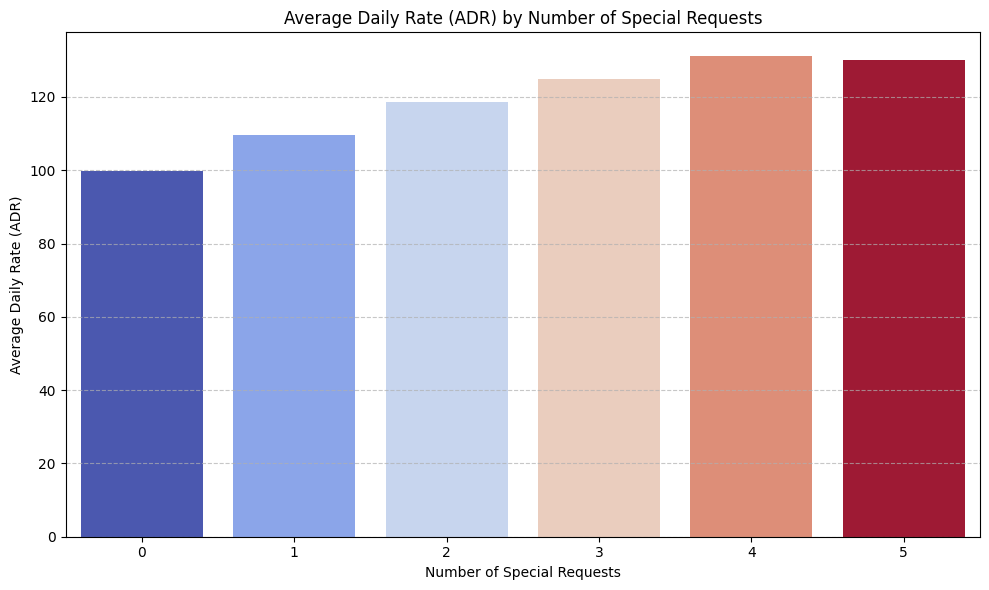

Average Daily Rate (ADR) by number of special requests:
   total_of_special_requests         adr
0                          0   99.682098
1                          1  109.652689
2                          2  118.574727
3                          3  125.000397
4                          4  131.088687
5                          5  129.980000


In [71]:
adr_by_special_requests = df.groupby('total_of_special_requests')['adr'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=adr_by_special_requests, x='total_of_special_requests', y='adr', palette='coolwarm', hue='total_of_special_requests', legend=False)
plt.title('Average Daily Rate (ADR) by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Average Daily Rate (ADR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Average Daily Rate (ADR) by number of special requests:")
print(adr_by_special_requests)

# Business Impact:
* Helps in understanding if guests with more special requests are associated with higher or lower ADR.
* Informs pricing strategies, potentially allowing for premium pricing for bookings with many special requests or offering incentives for fewer requests.
* Guides resource allocation for fulfilling special requests relative to the revenue generated.
* Helps in optimizing pricing strategies based on customer preferences.
*  Understands how special requests influence pricing.

### Average Stay Duration: Repeated Guests vs. New Guests

Average stay duration for repeated vs. new guests:
       guest_type  total_stay_nights
0       New Guest           3.700337
1  Repeated Guest           1.927086


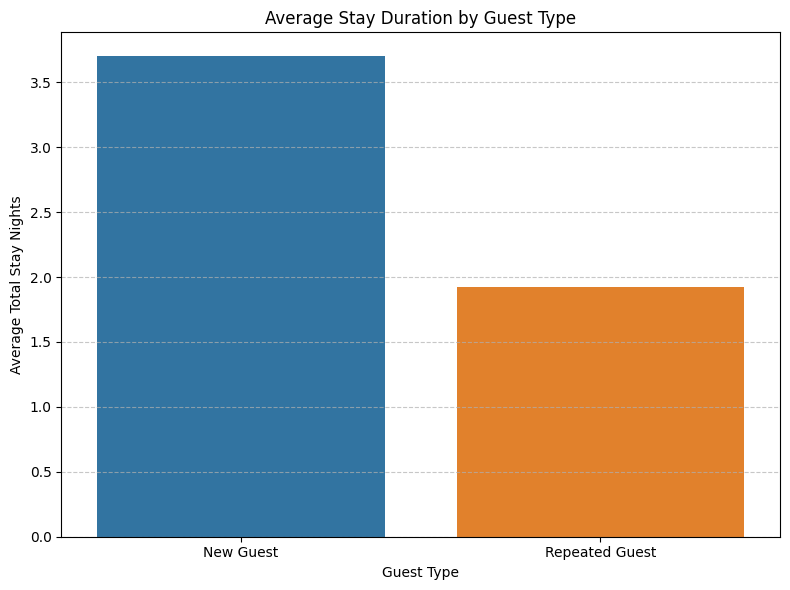

In [72]:
average_stay_duration_guests = df.groupby('is_repeated_guest')['total_stay_nights'].mean().reset_index()

# Map 0 and 1 to 'New Guest' and 'Repeated Guest' for better readability
average_stay_duration_guests['guest_type'] = average_stay_duration_guests['is_repeated_guest'].map({0: 'New Guest', 1: 'Repeated Guest'})

print("Average stay duration for repeated vs. new guests:")
print(average_stay_duration_guests[['guest_type', 'total_stay_nights']])

plt.figure(figsize=(8, 6))
sns.barplot(data=average_stay_duration_guests, x='guest_type', y='total_stay_nights', palette='tab10', hue='guest_type', legend=False)
plt.title('Average Stay Duration by Guest Type')
plt.xlabel('Guest Type')
plt.ylabel('Average Total Stay Nights')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Business Impact:
* Helps in tailoring loyalty programs and incentives to encourage longer stays from repeated guests.
* Provides insights for marketing efforts to attract new guests and convert them into repeated guests.
* Informs capacity planning and resource allocation based on the typical stay patterns of different guest segments.
* Helps in developing targeted loyalty programs and improving guest retention
* Understands guest behavior and loyalty.

### Room Type with the Highest Number of Bookings

The room type with the highest number of bookings is: A


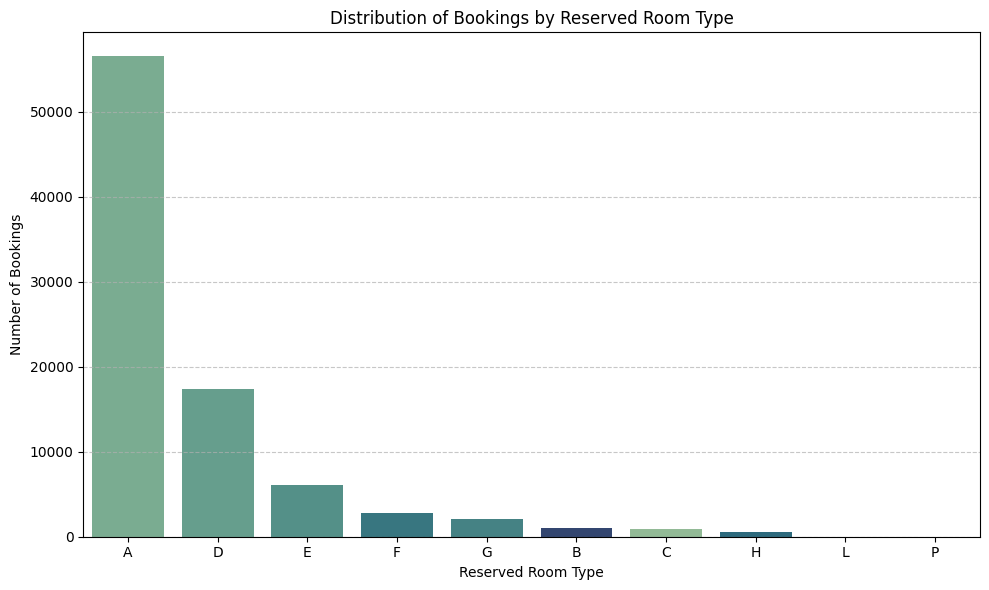

In [73]:
most_booked_room_type = df['reserved_room_type'].value_counts().idxmax()
print(f"The room type with the highest number of bookings is: {most_booked_room_type}")

# Optional: Visualize the distribution of room types
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='reserved_room_type', order=df['reserved_room_type'].value_counts().index, palette='crest', hue='reserved_room_type', legend=False)
plt.title('Distribution of Bookings by Reserved Room Type')
plt.xlabel('Reserved Room Type')
plt.ylabel('Number of Bookings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Business Impact:
* Helps in optimizing inventory management and resource allocation for popular room types.
* Informs marketing and pricing strategies for different room types.
* Identifies customer preferences and demand for specific room configurations.
* Helps in optimizing room availability and marketing strategies.
* Identifies the most popular room types.

### Factors Significantly Impacting Cancellation Rate (Logistic Regression Analysis)

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Define target and features
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# Identify numerical and categorical features
numerical_features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies',
                      'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'adr',
                      'required_car_parking_spaces', 'total_of_special_requests', 'total_stay_nights']
categorical_features = ['hotel', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type', 'is_repeated_guest']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a pipeline with preprocessing and logistic regression model
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', LogisticRegression(solver='liblinear', random_state=42))])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


## Key Features influencing the Cancellation Rate using Logistic Regression Model

After training the model, let's look at the coefficients to understand which features have the most impact on the cancellation rate. Positive coefficients indicate that an increase in the feature value leads to a higher probability of cancellation, while negative coefficients indicate a lower probability.

Top 15 Most Impactful Features on Cancellation Rate:


,Feature,Coefficient,Absolute_Coefficient
10,required_car_parking_spaces,-4.804728,4.804728
29,deposit_type_Non Refund,2.007698,2.007698
28,deposit_type_No Deposit,-1.731749,1.731749
20,market_segment_Offline TA/TO,-1.332978,1.332978
27,distribution_channel_Undefined,1.202722,1.202722
22,market_segment_Undefined,1.202681,1.202681
30,deposit_type_Refundable,-0.872124,0.872124
25,distribution_channel_GDS,-0.822074,0.822074
36,is_repeated_guest_1,-0.700092,0.700092
6,previous_cancellations,0.679502,0.679502


/tmp/ipykernel_5126/2596402066.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15), x='Coefficient', y='Feature', palette='coolwarm')


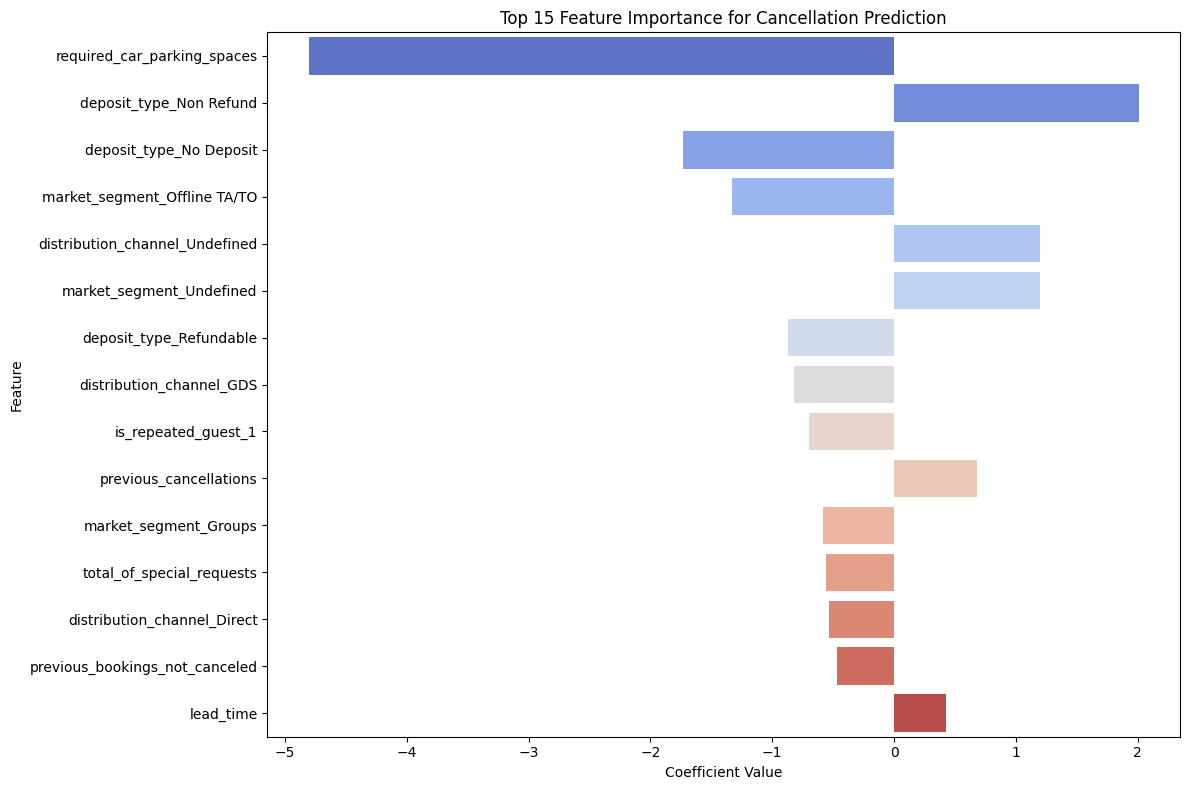

In [75]:
# Get feature names after one-hot encoding
onehot_features = model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(onehot_features)

# Get coefficients from the logistic regression model
coefficients = model.named_steps['classifier'].coef_[0]

# Create a DataFrame to store feature names and their coefficients
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute coefficient value to see the most impactful features
feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print("Top 15 Most Impactful Features on Cancellation Rate:")
display(feature_importance.head(15))

# Visualize the top N most impactful features
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Top 15 Feature Importance for Cancellation Prediction')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Business Impact:
* **Informed Decision Making:** Identifies key drivers of cancellation, allowing hotels to proactively address issues and develop targeted strategies.
* **Risk Management:** Helps in assessing the risk of cancellation for new bookings based on their characteristics.
* **Strategic Interventions:** Guides interventions such as offering incentives to guests with high lead times or those with specific deposit types to reduce cancellation rates.
* **Resource Optimization:** Allows for better allocation of resources to manage bookings with a higher likelihood of cancellation.

### Variation of ADR with Number of Adults, Children, and Babies (Multiple Regression Analysis)

In [76]:
import statsmodels.formula.api as smf

# Define the regression formula
# ADR as the dependent variable, adults, children, and babies as independent variables
formula = 'adr ~ adults + children + babies'

# Fit the OLS (Ordinary Least Squares) model
model_adr = smf.ols(formula=formula, data=df).fit()

# Print the model summary to analyze coefficients and R-squared
print(model_adr.summary())

                            OLS Regression Results                            
Dep. Variable:                    adr   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     5750.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        19:55:56   Log-Likelihood:            -4.6626e+05
No. Observations:               87376   AIC:                         9.325e+05
Df Residuals:                   87372   BIC:                         9.326e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     61.2096      0.538    113.696      0.0

# Business Impact:
*   **Dynamic Pricing Strategies:** The regression analysis provides quantifiable insights into how changes in the number of adults, children, and babies impact ADR. This allows hotels to implement more dynamic and precise pricing strategies, optimizing revenue based on booking demographics.
*   **Targeted Promotions:** Understanding which demographic factors significantly influence ADR can help in designing targeted promotional campaigns. For example, if 'children' has a strong positive correlation with ADR, family packages can be priced accordingly.
*   **Capacity and Resource Planning:** Insights into how different guest compositions affect ADR can aid in better planning of room types, amenities, and services. Hotels can optimize their offerings to cater to the most profitable guest segments.
*   **Demand Forecasting:** By identifying the relationship between guest demographics and ADR, hotels can improve their demand forecasting models, leading to more accurate revenue projections and better inventory management.
*  Helps in optimizing room rates based on guest demographics.
*  Understands how different guest compositions affect pricing.

### Impact of Booking Changes on Special Requests (Guest Satisfaction)

Average number of special requests by booking changes:


,booking_changes,total_of_special_requests
0,0,0.696593
1,1,0.682048
2,2,0.737172
3,3,0.826286
4,4,0.820225


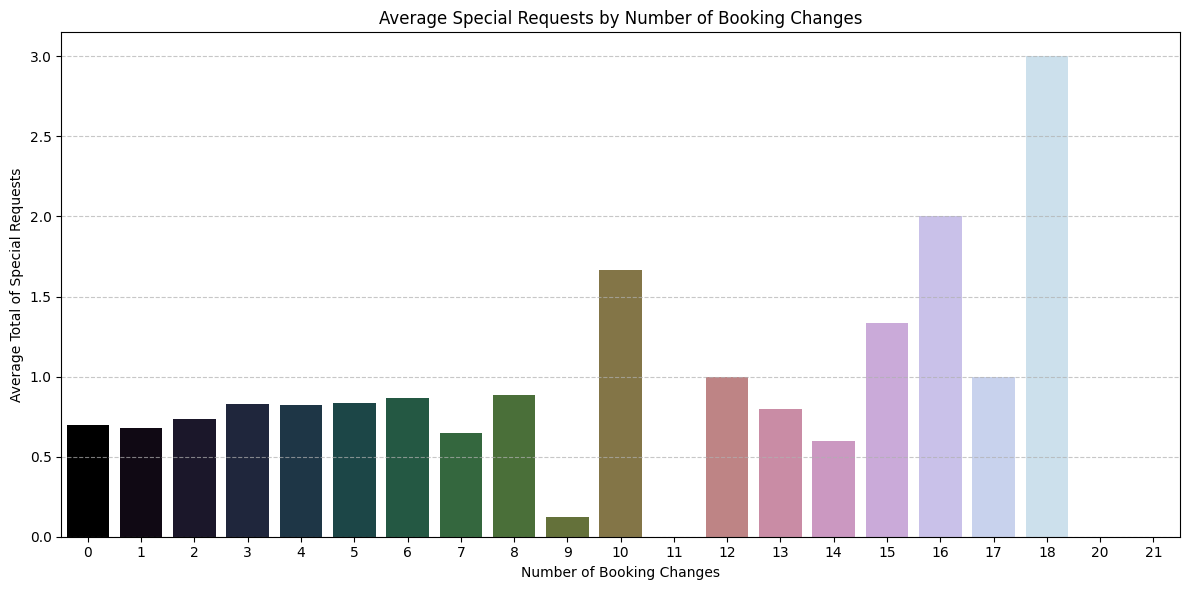

In [77]:
# Group by 'booking_changes' and calculate the mean of 'total_of_special_requests'
special_requests_by_changes = df.groupby('booking_changes')['total_of_special_requests'].mean().reset_index()

# Display the results
print("Average number of special requests by booking changes:")
display(special_requests_by_changes.head())

# Visualize the relationship
plt.figure(figsize=(12, 6))
sns.barplot(data=special_requests_by_changes, x='booking_changes', y='total_of_special_requests', palette='cubehelix', hue='booking_changes', legend=False)
plt.title('Average Special Requests by Number of Booking Changes')
plt.xlabel('Number of Booking Changes')
plt.ylabel('Average Total of Special Requests')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Business Impact:
*   **Customer Service Prioritization:** If there's a clear trend (e.g., more booking changes lead to fewer special requests), it suggests guests making changes might be less focused on personalization or are resigned to a simpler stay. This can help prioritize customer service efforts.
*   **Operational Efficiency:** Understanding this relationship can help optimize the handling of special requests. If guests with many changes tend to have fewer special requests, staff can anticipate this and streamline their process.
*   **Feedback Loop for Booking Process:** If a high number of booking changes consistently leads to a low number of special requests (or vice-versa), it might indicate issues or confusion in the initial booking process that needs to be addressed.
*   **Targeted Guest Communication:** Hotels can tailor communications based on the number of booking changes. For guests with several changes, a simplified confirmation or a focus on essential information might be more appropriate, while for guests with no changes, encouraging special requests could enhance satisfaction.
* Helps in improving booking flexibility and customer satisfaction.
* Understands the relationship between booking changes and guest needs.

### Seasonal Impact on Booking Cancellations

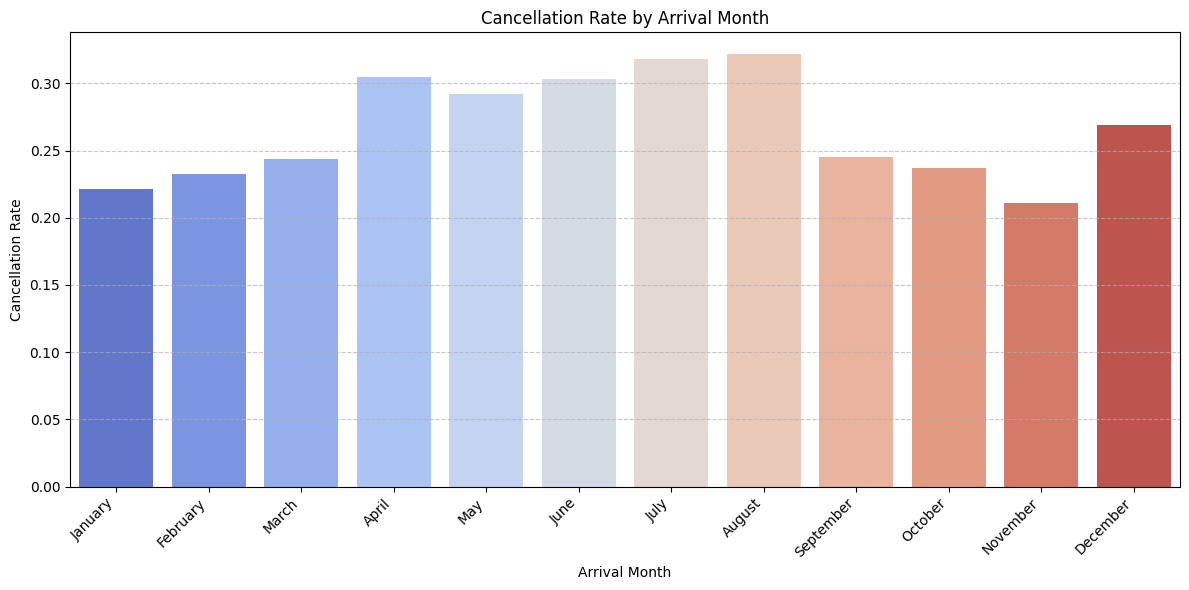

Cancellation Rate by Month:


,arrival_date_month,is_canceled
4,January,0.221275
3,February,0.232272
7,March,0.243675
0,April,0.304656
8,May,0.292280
6,June,0.303155
5,July,0.318019
1,August,0.321844
11,September,0.245441
10,October,0.236872


In [83]:
# Calculate cancellation rate per month
cancellation_rate_by_month = df.groupby('arrival_date_month')['is_canceled'].mean().reset_index()

# Define the correct order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
cancellation_rate_by_month['arrival_date_month'] = pd.Categorical(cancellation_rate_by_month['arrival_date_month'], categories=month_order, ordered=True)
cancellation_rate_by_month = cancellation_rate_by_month.sort_values('arrival_date_month')

# Visualize the seasonal impact on cancellation rates
plt.figure(figsize=(12, 6))
sns.barplot(data=cancellation_rate_by_month, x='arrival_date_month', y='is_canceled', palette='coolwarm', hue='arrival_date_month', legend=False)
plt.title('Cancellation Rate by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Cancellation Rate by Month:")
display(cancellation_rate_by_month)

# Business Impact:
*   **Targeted Prevention Strategies:** Identifying months with higher cancellation rates allows hotels to implement targeted prevention strategies during those periods, such as special offers for non-refundable bookings or enhanced customer engagement.
*   **Dynamic Pricing Adjustments:** Knowledge of seasonal cancellation trends can inform dynamic pricing models, potentially adjusting rates to compensate for anticipated cancellations or to encourage bookings during low-cancellation months.
*   **Resource Allocation:** Helps in optimizing staffing and inventory during periods of high cancellation risk to minimize losses and maximize efficiency.
*   **Marketing Campaign Timing:** Guides the timing of marketing campaigns, focusing efforts on periods that traditionally have lower cancellation rates or offering more flexible options during high-risk months to manage expectations.

### Booking Lead Time Distribution by Market Segment

/tmp/ipykernel_5126/2605539928.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='market_segment', y='lead_time', palette='tab10')


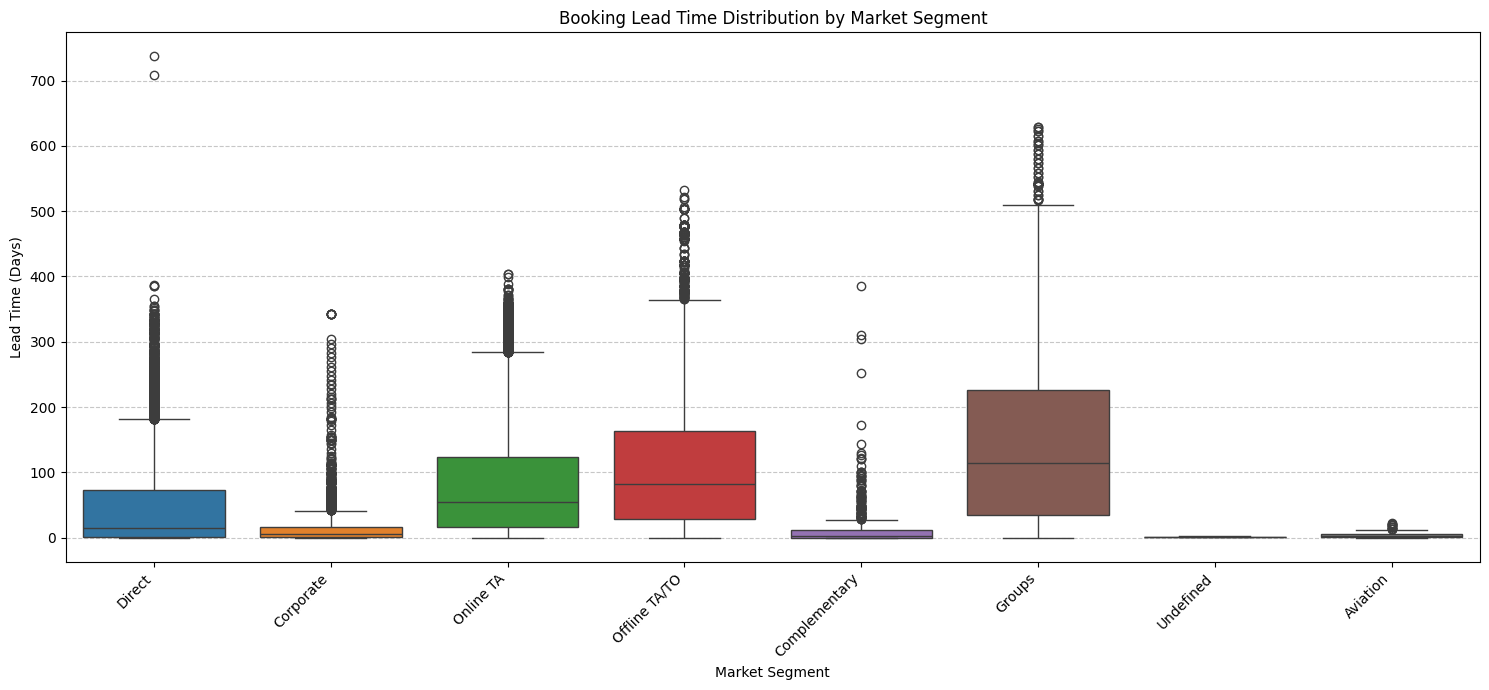

In [86]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='market_segment', y='lead_time', palette='tab10')
plt.title('Booking Lead Time Distribution by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Lead Time (Days)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Final Summary of Insights and Recommendations for Stakeholders

This analysis covered data preprocessing, exploratory data analysis, and advanced modeling to provide a holistic view of hotel booking patterns and their drivers.

### Key Insights:

1.  **Booking Volume & Preferences:**
    *   **City Hotels are more popular** than Resort Hotels in terms of booking volume.
    *   **August is the peak arrival month**, followed by July, in terms of both booking volume and revenue.
    *   **Online and Offline Travel Agencies (TA/TO)** are the dominant market segments, indicating high reliance on intermediary channels.
    *   **Portugal (PRT) is the country with the highest number of bookings.**
    *   **Room Type 'A'** is the most frequently reserved room type.

2.  **Cancellation Behavior:**
    *   **High lead times** are positively correlated with increased cancellation rates.
    *   **City Hotels exhibit a higher cancellation rate (30.04%)** compared to Resort Hotels (23.49%).
    *   **July and August show the highest cancellation rates**, while November and January have the lowest.
    *   **Special requests are a strong indicator of commitment**: Guests with more special requests are significantly less likely to cancel.
    *   **Key Factors Influencing Cancellations** (from Logistic Regression): `required_car_parking_spaces` (reduces cancellation likelihood), `deposit_type_Non Refund` (increases cancellation likelihood despite the name, likely due to pre-existing intent to cancel), and `deposit_type_No Deposit` (reduces cancellation likelihood).

3.  **Revenue & Pricing:**
    *   **August generates the highest total revenue** ($7.24 million).
    *   **Average Daily Rate (ADR) has an upward trend from 2015 to 2017.**
    *   **ADR increases with the number of special requests.**
    *   **ADR is significantly impacted by occupancy**: The number of adults, children, and babies positively influences ADR.
    *   City Hotels generally have a higher ADR (110.99) than Resort Hotels (99.04).

4.  **Guest Engagement & Loyalty:**
    *   **New guests tend to stay longer** (average 3.70 nights) compared to repeated guests (average 1.93 nights).
    *   **Average special requests per booking is 0.70**, indicating a general desire for personalized services.
    *   The number of booking changes does not significantly affect the average number of special requests.

### Recommendations for Stakeholders:

1.  **Optimize Cancellation Management:**
    *   **Targeted Prevention:** Implement proactive strategies for bookings with long lead times, especially in City Hotels during July and August. Consider re-confirmation calls, personalized offers, or flexible modification options to reduce cancellations.
    *   **Deposit Policy Review:** Re-evaluate the 'Non Refund' deposit type's effectiveness, as it paradoxically correlates with higher cancellations. Ensure clear communication and explore alternatives that genuinely deter cancellations.
    *   **Leverage Special Requests:** Actively encourage guests to make special requests during booking, as this indicates higher commitment and reduces cancellation risk.

2.  **Enhance Revenue Generation:**
    *   **Peak Season Strategy:** Capitalize on August's high revenue potential with premium pricing, upselling, and cross-selling opportunities. Develop specific packages for this month.
    *   **Dynamic Pricing with Demographics:** Utilize the insight that `adults`, `children`, and `babies` drive ADR. Develop dynamic pricing models that adjust rates based on expected occupancy composition.
    *   **Value-Added Services:** Promote special requests as value-added services, potentially offering tiered pricing for enhanced personalization to further boost ADR.

3.  **Refine Marketing & Sales Strategies:**
    *   **Channel Focus:** Strengthen relationships and optimize campaigns with online and offline travel agencies, given their significant contribution to bookings.
    *   **Geographic Targeting:** Intensify marketing efforts in Portugal (PRT).
    *   **Room Type Optimization:** Ensure ample availability and strategic pricing for Room Type 'A' due to its high demand. Explore opportunities to upsell or cross-sell other room types.
    *   **New Guest Retention:** Develop loyalty programs and incentives specifically designed to convert new guests, who tend to stay longer, into repeated guests with enhanced future engagement.

4.  **Improve Operational Efficiency:**
    *   **Car Parking Facilities:** Given that 8.37% of guests require car parking, ensure adequate facilities, especially in City Hotels, and integrate parking options clearly into the booking process.
    *   **Data Quality:** Continue to monitor and address data quality issues to prevent duplicate bookings and ensure accurate reporting, building upon the successful deduplication efforts.